# 09. Social Security Funds mechanisms

Analyse Social Security Funds revenue composition in national accounts, and the CFP internal budget systems separately, without merging two incompatible accounting boundaries.

**Reads**

- `outputs/tables/social_security_account_metrics.csv`
- `outputs/tables/social_security_system_metrics_2019_2025.csv`
- `outputs/tables/social_security_detail_metrics_2024_2025.csv`
- `outputs/tables/ssf_accounting_boundary_comparison.csv`
- `outputs/tables/revenue_expenditure_change_decomposition.csv`

**Writes**

- Nothing. All of these tables are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 10

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. National-accounts view

This is the ESA 2010 Social Security Funds sector, the same entity that appears
in the B.9 identity. Social contributions are the dominant revenue item, and the
contribution share is the composition metric used later in the report.

In [2]:
ssf = pd.read_csv(TABLES / 'social_security_account_metrics.csv')
account_columns = [
    'year',
    'total_revenue_m_eur',
    'social_contributions_m_eur',
    'contributions_share_total_revenue',
    'total_expenditure_m_eur',
    'balance_m_eur',
]
display(ssf[account_columns].tail(12).round(3))

,year,total_revenue_m_eur,social_contributions_m_eur,contributions_share_total_revenue,total_expenditure_m_eur,balance_m_eur
33,2014,23744.982,13546.404,0.570,22937.346,807.636
34,2015,24091.596,14131.051,0.587,22963.062,1128.534
35,2016,24800.032,14841.064,0.598,23230.089,1569.943
36,2017,25876.981,15883.272,0.614,23634.427,2242.554
37,2018,26675.139,17049.069,0.639,24640.347,2034.792
38,2019,28812.083,18532.578,0.643,25836.613,2975.470
39,2020,31320.770,18844.001,0.602,29122.861,2197.909
40,2021,32296.492,20273.610,0.628,29828.175,2468.317
41,2022,34723.692,22563.085,0.650,30424.288,4299.404
42,2023,37866.691,25368.629,0.670,32146.532,5720.159


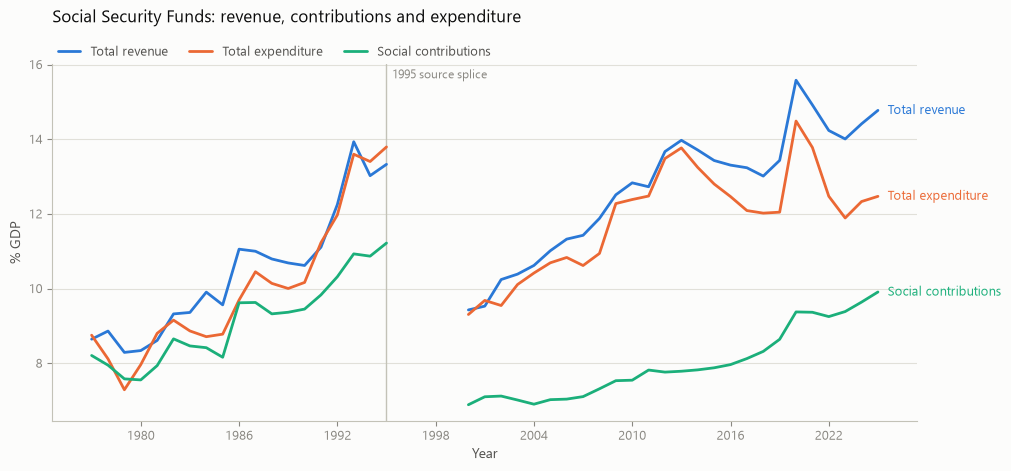

In [3]:
figure = figures.social_security_composition(ssf)

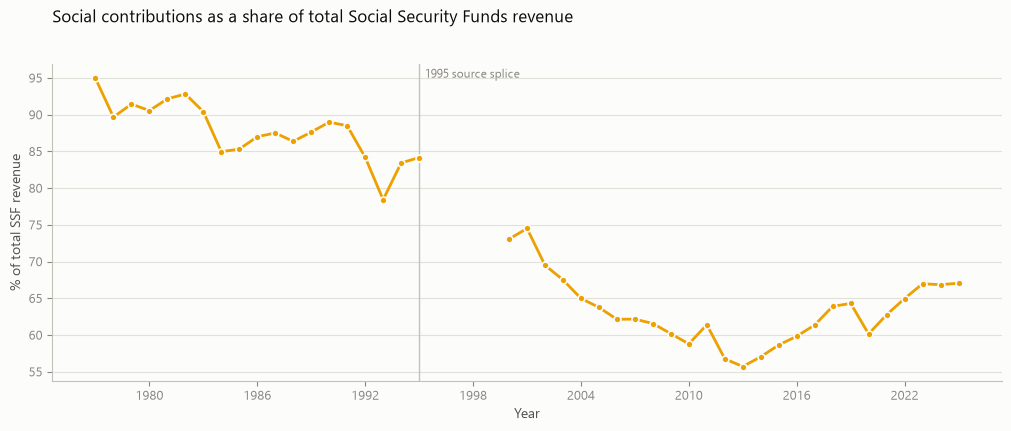

In [4]:
figure = figures.social_security_contribution_share(ssf)

## 2. A different boundary: the CFP budget systems

The CFP Social Security report decomposes the system into the Previdential
system, the Social Protection of Citizenship system and special regimes. These
are **budget-execution** aggregates. They are not a partition of the ESA 2010
Social Security Funds balance and are never added to it.

In [5]:
systems = pd.read_csv(TABLES / 'social_security_system_metrics_2019_2025.csv')
detail = pd.read_csv(TABLES / 'social_security_detail_metrics_2024_2025.csv')
display(systems.round(1))
display(detail.set_index('year').T)

,year,citizenship_system_balance_m_eur,previdential_system_balance_m_eur,special_regimes_balance_m_eur,source,system_sum_m_eur
0,2019,443,2333,0,CFP Social Security 2025 report underlying data,2776
1,2020,423,1649,0,CFP Social Security 2025 report underlying data,2072
2,2021,653,1695,0,CFP Social Security 2025 report underlying data,2348
3,2022,-110,4172,0,CFP Social Security 2025 report underlying data,4062
4,2023,1,5485,0,CFP Social Security 2025 report underlying data,5486
5,2024,-245,5840,0,CFP Social Security 2025 report underlying data,5595
6,2025,-55,6712,0,CFP Social Security 2025 report underlying data,6657


year,2024,2025
social_contributions_m_eur,27688,30152
state_budget_transfers_m_eur,9199,9956
state_budget_lbss_transfers_m_eur,8620,9442
rsi_expenditure_m_eur,358,342
professional_training_subsidies_m_eur,41,96
social_security_budget_balance_m_eur,5591,6672
previdential_revenue_m_eur,30107,32679
previdential_contributions_m_eur,27688,30152
previdential_state_transfers_m_eur,322,317
previdential_training_employment_expenditure_m_eur,950,1031


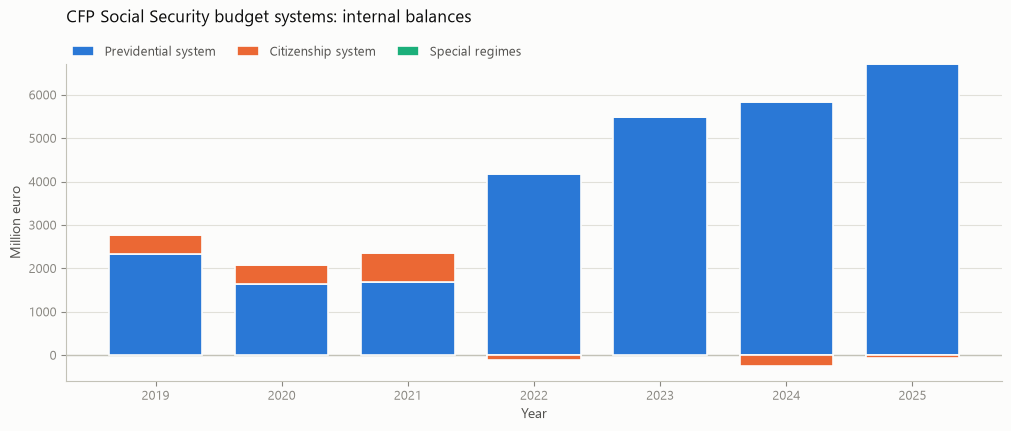

In [6]:
figure = figures.social_security_systems(systems)

Across the years the CFP publishes, the movement in the internal balances is
concentrated in the Previdential system, while the Citizenship system stays small
in both directions. That is a description of the published series, not an account
of what caused it.

In [7]:
movement = systems.set_index('year')[
    [
        'previdential_system_balance_m_eur',
        'citizenship_system_balance_m_eur',
        'special_regimes_balance_m_eur',
    ]
]
display(movement)
display((movement.iloc[-1] - movement.iloc[0]).rename('change over the published years').to_frame())

,previdential_system_balance_m_eur,citizenship_system_balance_m_eur,special_regimes_balance_m_eur
year,,,
2019,2333,443,0
2020,1649,423,0
2021,1695,653,0
2022,4172,-110,0
2023,5485,1,0
2024,5840,-245,0
2025,6712,-55,0


,change over the published years
previdential_system_balance_m_eur,4379
citizenship_system_balance_m_eur,-498
special_regimes_balance_m_eur,0


## 3. The contribution base

The decomposition above locates the movement inside the fiscal accounts. It does not
relate it to anything outside them. Contributions are levied on wages, so the natural
base is the aggregate wage bill of the economy, and the change in contributions splits
exactly into a base effect and a rate effect:

$$\Delta C_t = 	au_{t-1}\,\Delta W_t + W_{t-1}\,\Delta 	au_t + \Delta W_t\,\Delta 	au_t,
\qquad 	au_t = C_t / W_t.$$

The wage bill splits again into employees and the average wage per employee. Both
decompositions are exact; the interaction terms are carried rather than dropped.

`tau` is **not** a statutory rate. National-accounts contributions include imputed
contributions and bases other than employee wages, so it moves with coverage and
composition as well as with legislated rates.

In [8]:
base = pd.read_csv(PROCESSED / 'contribution_base_panel_1995_2025.csv')
decomposition = pd.read_csv(TABLES / 'contribution_change_decomposition.csv')
print('effective ratio, first and last:',
      round(float(base['effective_contribution_rate'].iloc[0]), 3),
      round(float(base['effective_contribution_rate'].iloc[-1]), 3))
print('max |contributions closure|:', float(decomposition['contributions_closure_error_m_eur'].abs().max()))
print('max |wage bill closure|   :', float(decomposition['wage_bill_closure_error_m_eur'].abs().max()))
display(
    decomposition[
        [
            'year',
            'contributions_change_m_eur',
            'from_wage_bill_m_eur',
            'from_effective_rate_m_eur',
            'from_employment_m_eur',
            'from_average_wage_m_eur',
        ]
    ].tail(8).round(1)
)

effective ratio, first and last: 0.26 0.265
max |contributions closure|: 3.183231456e-12
max |wage bill closure|   : 8.867573342e-12


,year,contributions_change_m_eur,from_wage_bill_m_eur,from_effective_rate_m_eur,from_employment_m_eur,from_average_wage_m_eur
17,2018,1165.8,947.0,206.4,1423.3,2521.0
18,2019,1483.5,1013.9,443.3,477.9,3722.1
19,2020,311.4,28.5,282.5,-1399.6,1544.0
20,2021,1429.6,1267.6,151.8,852.2,4171.8
21,2022,2289.5,2109.6,162.9,2985.4,5194.1
22,2023,2805.5,2685.3,107.4,2000.2,8383.1
23,2024,2557.3,2056.4,463.3,992.4,6995.6
24,2025,2467.6,1870.2,560.0,2252.7,4842.3


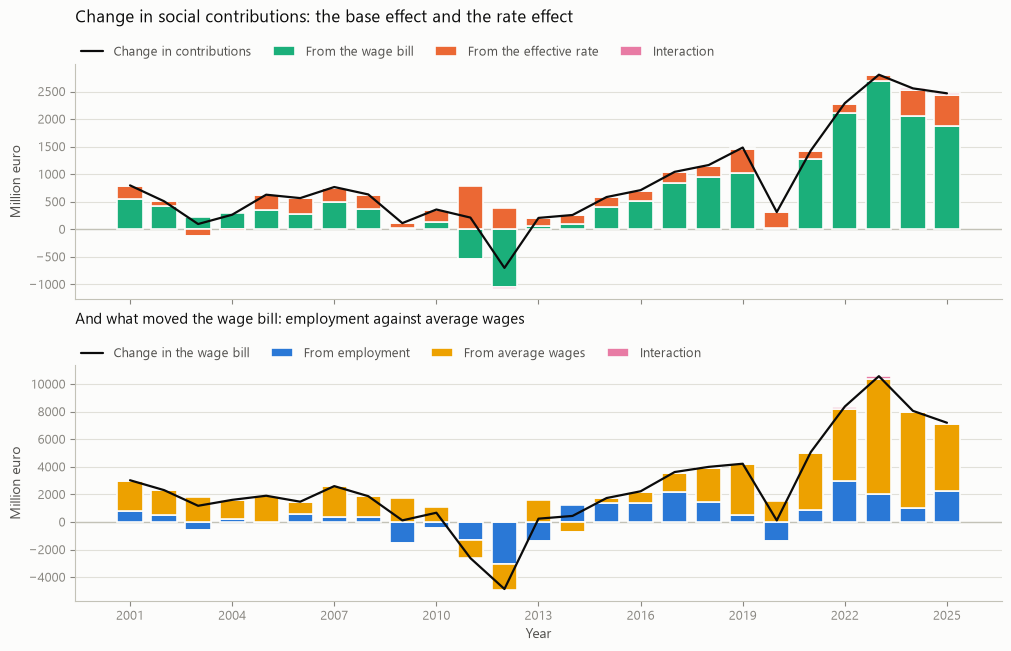

In [9]:
figure = figures.contribution_base_decomposition(decomposition)

No change is computed across the 1995-to-2000 gap in subsector accounts. That is not
a formality: bridging it treats five years of wage-bill growth as one year, which moves
the regression slope below from 0.25 to 0.13 and its fit from 0.93 to 0.40 on a single
contaminated observation.

In [10]:
regression = pd.read_csv(TABLES / 'contribution_wage_bill_regression.csv')
display(regression.round(4))

,n,first_year,last_year,r_squared,wage_bill_coef,wage_bill_se_hac,wage_bill_pvalue_hac,intercept_m_eur,mean_effective_rate,coef_minus_mean_rate
0,25,2001,2025,0.9262,0.248,0.0222,0.0,215.3947,0.2212,0.0268


## 4. Why the two boundaries must not be interchanged

This is the point the two layers exist to make. The ESA 2010 Social Security Funds
balance is the B.9 term that enters the general-government identity. The budget
systems are a different accounting object. They are close, but the difference is
non-zero in **every** overlapping year, which is exactly why a figure quoted from
the budget documents cannot be substituted for the national-accounts one.

The columns below are never added, netted or reconciled. The difference column
measures how far apart they are.

In [11]:
boundary = pd.read_csv(TABLES / 'ssf_accounting_boundary_comparison.csv')
display(boundary.round(3))
print(
    'difference range (M EUR):',
    round(float(boundary['boundary_difference_m_eur'].min()), 1),
    'to',
    round(float(boundary['boundary_difference_m_eur'].max()), 1),
)
print('years where the two are equal:', int((boundary['boundary_difference_m_eur'] == 0).sum()))

,year,esa2010_ssf_balance_m_eur,budget_system_total_m_eur,previdential_system_balance_m_eur,citizenship_system_balance_m_eur,special_regimes_balance_m_eur,boundary_difference_m_eur,boundary_difference_share_esa_balance
0,2019,2975,2776,2333,443,0,199,0.067
1,2020,2198,2072,1649,423,0,126,0.057
2,2021,2468,2348,1695,653,0,120,0.049
3,2022,4299,4062,4172,-110,0,237,0.055
4,2023,5720,5486,5485,1,0,234,0.041
5,2024,6031,5595,5840,-245,0,436,0.072
6,2025,7065,6657,6712,-55,0,408,0.058


difference range (M EUR): 120.0 to 436.0
years where the two are equal: 0


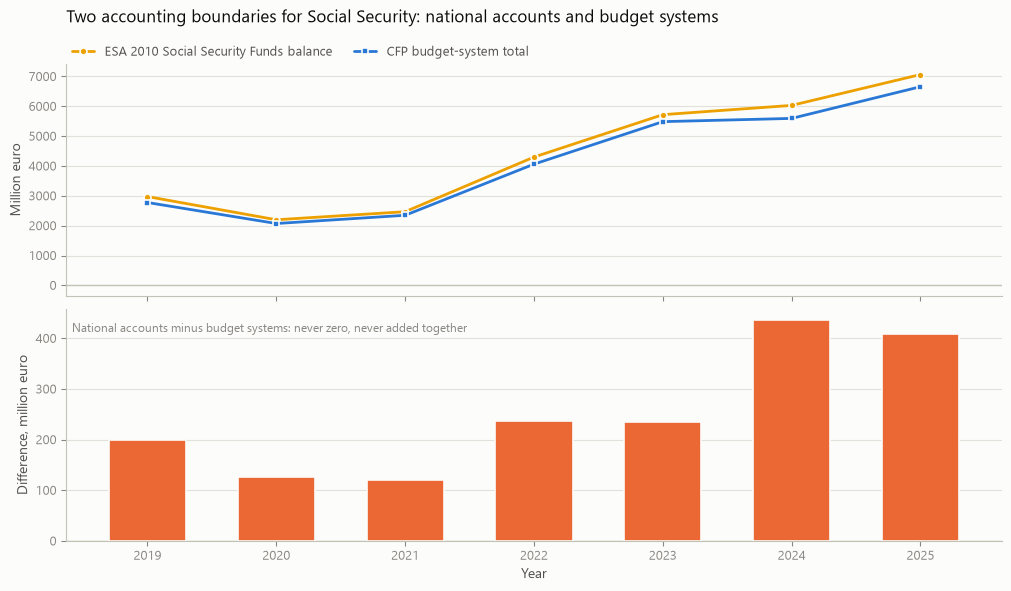

In [12]:
figure = figures.ssf_accounting_boundary(boundary)

## 5. Contribution dynamics

The change in contributions is the revenue-side mechanism behind the national-accounts
balance. It is shown against the change in total revenue and expenditure so the
composition of each annual movement is visible.

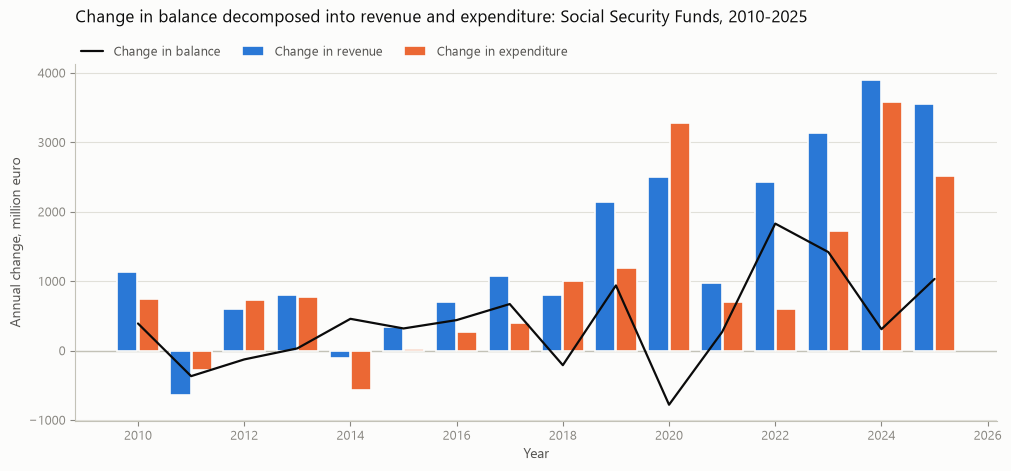

In [13]:
changes = pd.read_csv(TABLES / 'revenue_expenditure_change_decomposition.csv')
figure = figures.revenue_expenditure_changes(
    changes, 'social_security_funds', start_year=2010, end_year=int(changes['year'].max())
)

## Interpretation limits

1. The two layers in this notebook have **different accounting boundaries** and
   are reported side by side, never combined. Section 3 quantifies the gap rather
   than closing it.
2. This report does **not** subtract State transfers from the Social Security
   balance and call the remainder an underlying balance. Which transfers finance
   which statutory responsibility is a legal question, not an accounting one.
3. The contribution share is a **composition ratio**. It says nothing about the
   adequacy or sustainability of the system.
4. Internal system tables cover **2019-2025 only**, with detail for 2024-2025, so
   the movement described above is a short window.
5. Attributing the movement to one system is an **accounting** statement. No
   mechanism, policy change or demographic driver is identified here.

---

[Previous: 08. Structural mean shifts](08_structural_breaks.ipynb) | [Next: 10. Intergovernmental transfer sensitivity](10_intergovernmental_transfers.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```